# Week 7: Baseline OLS Model

## Goals
- Build a clean baseline regression dataset
- Estimate a simple OLS model
- Check coefficient directions and model fit
- Prepare for later spatial analysis

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import statsmodels.api as sm

In [ ]:
import sys
from pathlib import Path

_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from tokyo_foreigners.paths import PROJECT_ROOT, DATA_RAW_DIR

project_root = PROJECT_ROOT
data_raw = DATA_RAW_DIR

print(project_root)
print(data_raw)

week6_path = data_raw / "tokyo_features_v2.geojson"
tokyo = gpd.read_file(week6_path)

print(tokyo.shape)
print(tokyo.columns.tolist())
tokyo.head()

E:\rsch\laborJapan
E:\rsch\laborJapan\data_raw


In [3]:
tokyo["foreign_ratio"] = pd.to_numeric(tokyo["foreign_ratio"], errors="coerce")
tokyo["log_dist_to_station_m"] = pd.to_numeric(tokyo["log_dist_to_station_m"], errors="coerce")
tokyo["log_median_land_price_jpy"] = pd.to_numeric(tokyo["log_median_land_price_jpy"], errors="coerce")

model_df = tokyo[[
    "N03_007", "N03_001", "N03_004", "N03_005",
    "foreign_ratio",
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "geometry"
]].copy()

model_df = model_df.dropna(
    subset=["foreign_ratio", "log_dist_to_station_m", "log_median_land_price_jpy"]
).copy()

print(model_df.shape)
model_df[["foreign_ratio", "log_dist_to_station_m", "log_median_land_price_jpy"]].describe()

(218, 8)


,foreign_ratio,log_dist_to_station_m,log_median_land_price_jpy
count,218.000000,218.000000,218.000000
mean,0.031358,6.884865,11.749580
std,0.020476,1.041608,1.012919
min,0.006770,1.449327,9.332646
25%,0.018463,6.339965,11.020488
50%,0.025731,6.912556,11.790558
75%,0.035370,7.596603,12.422668
max,0.125698,8.995162,15.021482


In [4]:
X = model_df[["log_dist_to_station_m", "log_median_land_price_jpy"]]
X = sm.add_constant(X)
y = model_df["foreign_ratio"]

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          foreign_ratio   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     21.11
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           4.26e-09
Time:                        13:15:36   Log-Likelihood:                 558.41
No. Observations:                 218   AIC:                            -1111.
Df Residuals:                     215   BIC:                            -1101.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [5]:
coef_table = pd.DataFrame({
    "coef": ols_model.params,
    "std_err": ols_model.bse,
    "t": ols_model.tvalues,
    "p_value": ols_model.pvalues
})
coef_table

,coef,std_err,t,p_value
const,-0.022374,0.024087,-0.928861,0.354003
log_dist_to_station_m,-0.002869,0.001437,-1.996438,0.047148
log_median_land_price_jpy,0.006254,0.001478,4.232501,0.000034


In [6]:
model_df["ols_fitted"] = ols_model.fittedvalues
model_df["ols_resid"] = ols_model.resid

model_df[["foreign_ratio", "ols_fitted", "ols_resid"]].head()

,foreign_ratio,ols_fitted,ols_resid
0,0.015422,0.030280,-0.014858
1,0.018455,0.036036,-0.017581
2,0.027177,0.047579,-0.020402
3,0.021768,0.030391,-0.008623
4,0.019989,0.043603,-0.023614


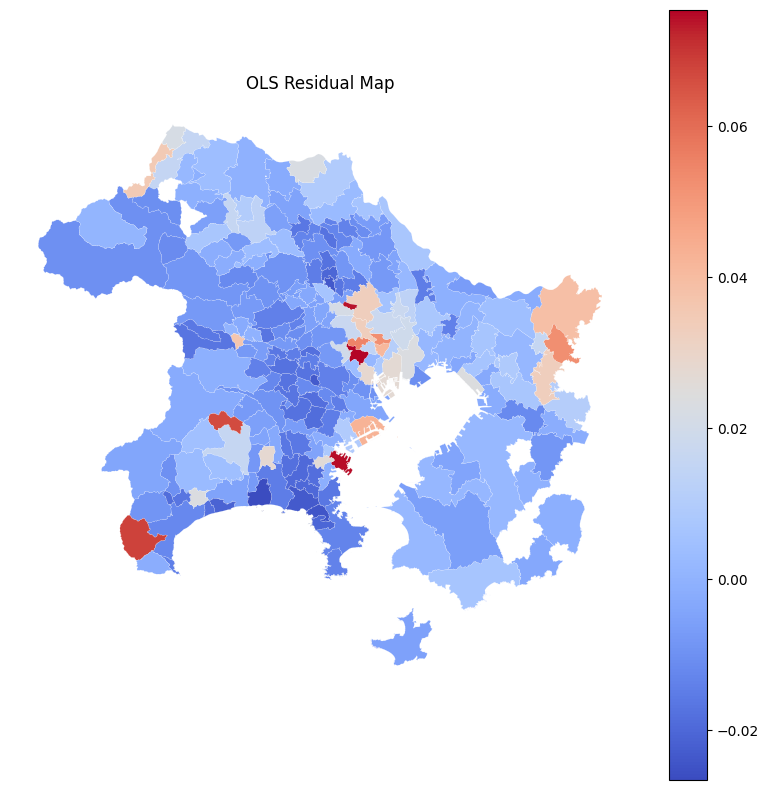

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

model_df.plot(
    column="ols_resid",
    cmap="coolwarm",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("OLS Residual Map")
ax.set_axis_off()
plt.show()

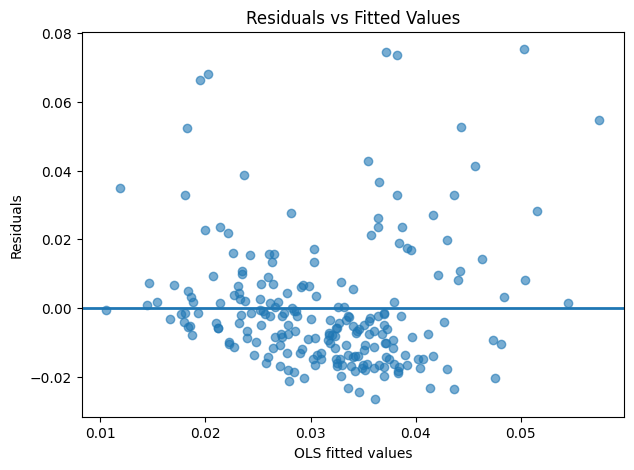

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(model_df["ols_fitted"], model_df["ols_resid"], alpha=0.6)
ax.axhline(0, linewidth=2)

ax.set_xlabel("OLS fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted Values")

plt.show()

In [9]:
model_df[[
    "N03_001", "N03_004", "N03_005",
    "foreign_ratio", "ols_fitted", "ols_resid"
]].sort_values("ols_resid", ascending=False).head(10)

,N03_001,N03_004,N03_005,foreign_ratio,ols_fitted,ols_resid
112,東京都,新宿区,,0.125698,0.050328,0.075370
163,神奈川県,横浜市,中区,0.111693,0.037152,0.074541
28,埼玉県,蕨市,,0.112048,0.038256,0.073793
213,神奈川県,箱根町,,0.088384,0.020214,0.068170
216,神奈川県,愛川町,,0.085878,0.019479,0.066399
124,東京都,豊島区,,0.112230,0.057482,0.054748
126,東京都,荒川区,,0.096918,0.044342,0.052576
103,千葉県,富里市,,0.070770,0.018284,0.052485
178,神奈川県,川崎市,川崎区,0.078258,0.035482,0.042776
114,東京都,台東区,,0.087034,0.045644,0.041390


In [10]:
model_df[[
    "N03_001", "N03_004", "N03_005",
    "foreign_ratio", "ols_fitted", "ols_resid"
]].sort_values("ols_resid", ascending=True).head(10)

,N03_001,N03_004,N03_005,foreign_ratio,ols_fitted,ols_resid
193,神奈川県,茅ヶ崎市,,0.009532,0.036101,-0.026569
194,神奈川県,逗子市,,0.010306,0.034659,-0.024353
4,埼玉県,さいたま市,中央区,0.019989,0.043603,-0.023614
190,神奈川県,鎌倉市,,0.010289,0.033528,-0.023239
148,東京都,狛江市,,0.018173,0.041380,-0.023207
206,神奈川県,大磯町,,0.006770,0.027947,-0.021177
2,埼玉県,さいたま市,大宮区,0.027177,0.047579,-0.020402
204,神奈川県,葉山町,,0.009048,0.029417,-0.020369
174,神奈川県,横浜市,栄区,0.013065,0.032895,-0.019830
169,神奈川県,横浜市,戸塚区,0.017263,0.036948,-0.019685


In [11]:
week7_geojson = data_raw / "tokyo_features_v3_ols.geojson"

model_df.to_file(week7_geojson, driver="GeoJSON")

print(week7_geojson)
print(week7_geojson.exists())

e:\rsch\laborJapan\data_raw\tokyo_features_v3_ols.geojson
True


In [12]:
model_df.drop(columns="geometry").to_csv(
    data_raw / "tokyo_features_v3_ols.csv",
    index=False,
    encoding="utf-8-sig"
)

## Residual-based interpretation

The baseline OLS model captures some general relationship between foreign population ratio, station accessibility, and residential land price, but substantial unexplained structure remains.

Three patterns are especially notable:

1. The residual-versus-fitted plot does not show a purely random cloud around zero. Several large positive residuals remain, suggesting that the model underestimates some highly concentrated foreign-population areas.

2. The largest positive residuals are found in highly urbanized and internationally connected districts such as Shinjuku-ku, Yokohama Naka-ku, Warabi-shi, Kawasaki-ku, Taito-ku, Arakawa-ku, and Toshima-ku. These areas likely reflect additional mechanisms not captured by the current two-variable model.

3. The largest negative residuals are found in more suburban or residential-oriented municipalities such as Chigasaki-shi, Zushi-shi, Kamakura-shi, Komae-shi, Oiso-machi, and Yokohama’s outer wards. This suggests that the baseline model overpredicts foreign population shares in some non-core areas.

Overall, the residual structure strongly suggests that spatial dependence and spatial heterogeneity remain, which justifies moving to spatial residual diagnostics in the next stage.